# Soccer AI: Evaluación de Progreso Avanzada

Este cuadernillo analiza el rendimiento de los agentes usando Aprendizaje por Refuerzo.

### Definiciones:
1. **Tasa de Éxito**: Porcentaje de acciones que resultaron en una recompensa positiva.
2. **Eficiencia de Aprendizaje**: Qué tan rápido está subiendo la recompensa promedio a lo largo del tiempo.

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import os

roles = ['attacker', 'defender', 'goalkeeper']
base_path = 'pesos_jugadores'

def analizar_agentes():
    datos = {}
    for role in roles:
        path = f"{base_path}/{role}/shared_weights.npz"
        if os.path.exists(path):
            d = np.load(path)
            history = d['history'] if 'history' in d else np.array([])
            lessons = int(d['lessons']) if 'lessons' in d else 0
            
            # Tasa de éxito: % de veces que la recompensa promedio fue positiva
            exito = (np.sum(history > 0) / len(history)) * 100 if len(history) > 0 else 0
            
            # Eficiencia: Pendiente de la curva de aprendizaje (últimos 5 puntos)
            if len(history) > 5:
                eficiencia = (history[-1] - history[-5]) / 5
            else:
                eficiencia = 0
                
            datos[role] = {
                'lessons': lessons,
                'history': history,
                'exito': exito,
                'eficiencia': eficiencia
            }
    return datos

resumen = analizar_agentes()
print("Análisis completado.")

Análisis completado.


## 📈 Curva de Aprendizaje por Agente
Aquí vemos la recompensa promedio. Si la línea sube, el agente está aprendiendo a jugar mejor.

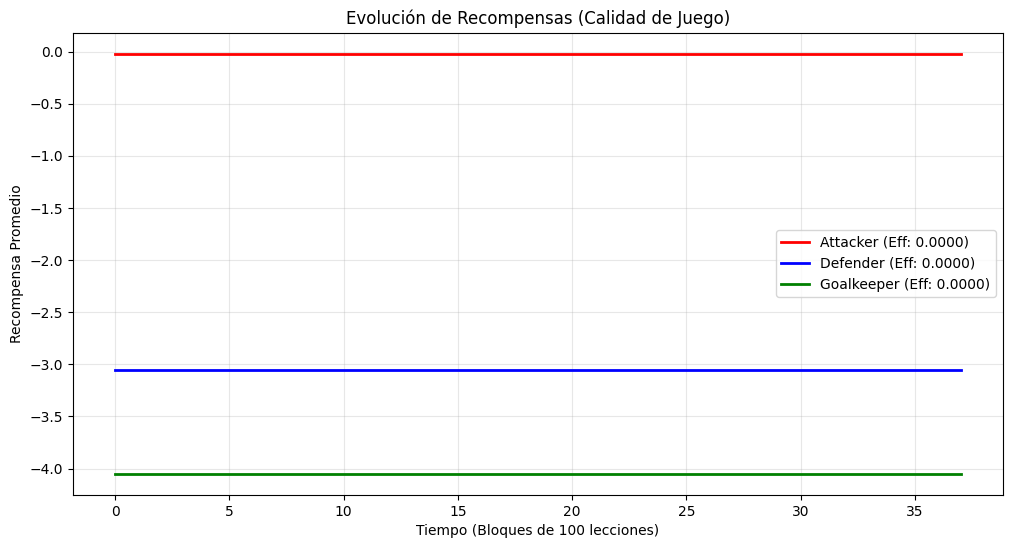

In [79]:
plt.figure(figsize=(12, 6))
colors = {'attacker': 'red', 'defender': 'blue', 'goalkeeper': 'green'}

for role, info in resumen.items():
    if len(info['history']) > 0:
        # Aplicamos un suavizado para que se vea mejor
        smooth_h = np.convolve(info['history'], np.ones(5)/5, mode='valid')
        plt.plot(smooth_h, label=f"{role.capitalize()} (Eff: {info['eficiencia']:.4f})", color=colors[role], linewidth=2)

plt.title('Evolución de Recompensas (Calidad de Juego)')
plt.xlabel('Tiempo (Bloques de 100 lecciones)')
plt.ylabel('Recompensa Promedio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Tasa de Éxito por Rol
Muestra qué tan 'acertadas' son las decisiones de cada rol.

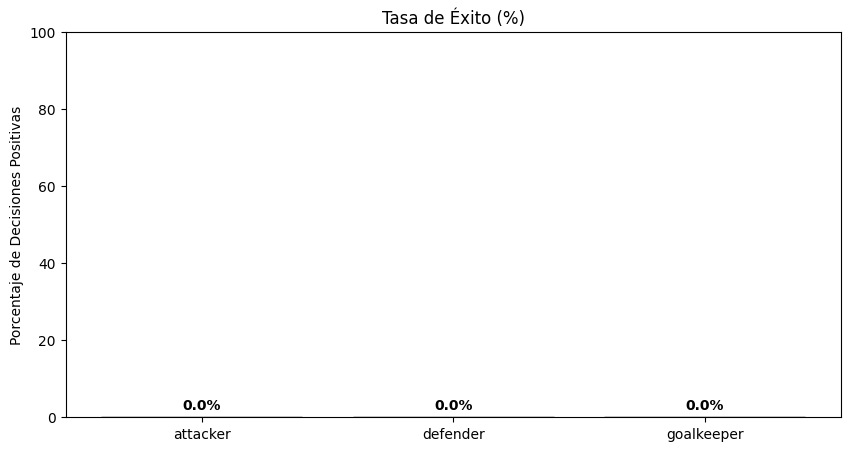

In [80]:
roles_list = list(resumen.keys())
exitos = [info['exito'] for info in resumen.values()]

plt.figure(figsize=(10, 5))
bars = plt.bar(roles_list, exitos, color=['#ffcccc', '#ccccff', '#ccffcc'], edgecolor='black')
plt.title('Tasa de Éxito (%)')
plt.ylim(0, 100)
plt.ylabel('Porcentaje de Decisiones Positivas')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', fontweight='bold')

plt.show()

###  Conclusiones
1. **Tasa de Éxito**: Si está por debajo del 50%, el agente todavía está cometiendo muchos errores (como salirse de la cancha o alejarse del balón).
2. **Eficiencia**: Si el número es positivo, el agente está mejorando. Si es negativo, el agente está 'confundido' o el rival es demasiado fuerte para su nivel actual.